# Ising finite-size critical scaling

This notebook analyzes the existing 1,000 independent seeds for $L=16,32,64,128$. Magnetization and energy are calculated directly from every saved spin configuration. It estimates the pseudocritical temperature using:

1. the peak of $-d\langle |m|\rangle/dT$;
2. the susceptibility peak;
3. the specific-heat peak;
4. crossings of the Binder cumulant $U_4$.

It then tests standard 2D Ising finite-size relations, including $T_c(L)=T_c+aL^{-1/\nu}$, $\chi_{\max}\sim L^{\gamma/\nu}$, $\langle|m|\rangle_{T_c}\sim L^{-\beta/\nu}$, and derivative slopes $\sim L^{1/\nu}$.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline, PchipInterpolator
from scipy.optimize import brentq
from scipy.stats import linregress

SIZES = np.array([16, 32, 64, 128])
N_RUNS = 1_000
N_TEMPERATURES = 31
BINS_PER_TEMPERATURE = 10
EXACT_TC = 2.0 / np.log(1.0 + np.sqrt(2.0))
TEMPERATURES = np.array([1.50, 1.60, 1.70, 1.80, 1.90, 2.00, 2.05, 2.10, 2.15, 2.18, 2.20, 2.22, 2.24, 2.25, 2.26, 2.27, 2.28, 2.29, 2.30, 2.32, 2.34, 2.36, 2.38, 2.40, 2.45, 2.50, 2.60, 2.70, 2.80, 2.90, 3.00])

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parents[1]
SHARED_RAW = Path.home() / "senior-thesis" / "data" / "raw" / "finite_size"
L16_RAW = Path.home() / "scratch" / "senior thesis" / "data" / "raw"
OUTPUT_ROOT = Path.home() / "senior-thesis" / "data" / "processed" / "finite_size"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Exact square-lattice Ising Tc = {EXACT_TC:.9f}")

Exact square-lattice Ising Tc = 2.269185314


## Cache seed-level moments

For each seed and temperature, the ten saved configurations are reduced to $\langle|m|\rangle$, $\langle m^2\rangle$, $\langle m^4\rangle$, $\langle e\rangle$, and $\langle e^2\rangle$. Keeping seed-level values preserves independent units for later uncertainty estimates.

In [2]:
def run_directories(size):
    root = L16_RAW if size == 16 else SHARED_RAW / f"L{size}"
    pattern = "ising16_tc_[0-9]*" if size == 16 else f"ising{size}_tc_[0-9]*"
    runs = sorted(root.glob(pattern), key=lambda p: int(p.name.rsplit("_", 1)[1]))
    assert len(runs) == N_RUNS, f"L={size}: found {len(runs)} runs"
    return runs

def cache_moments(size):
    cache = OUTPUT_ROOT / f"ising{size}_seed_temperature_moments.npz"
    if cache.exists():
        return dict(np.load(cache))

    moments = np.empty((N_RUNS, N_TEMPERATURES, 5), dtype=np.float64)
    for run_index, run_dir in enumerate(run_directories(size)):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, size, size)
        m = spins.mean(axis=(2, 3), dtype=np.float64)
        horizontal = (spins * np.roll(spins, -1, axis=3)).mean(axis=(2, 3), dtype=np.float64)
        vertical = (spins * np.roll(spins, -1, axis=2)).mean(axis=(2, 3), dtype=np.float64)
        e = -(horizontal + vertical)
        moments[run_index, :, 0] = np.abs(m).mean(axis=1)
        moments[run_index, :, 1] = (m ** 2).mean(axis=1)
        moments[run_index, :, 2] = (m ** 4).mean(axis=1)
        moments[run_index, :, 3] = e.mean(axis=1)
        moments[run_index, :, 4] = (e ** 2).mean(axis=1)
        if (run_index + 1) % 100 == 0:
            print(f"L={size}: reduced {run_index + 1}/{N_RUNS} seeds")
    np.savez(cache, moments=moments, temperatures=TEMPERATURES)
    return {"moments": moments, "temperatures": TEMPERATURES}

moment_data = {size: cache_moments(size) for size in SIZES}

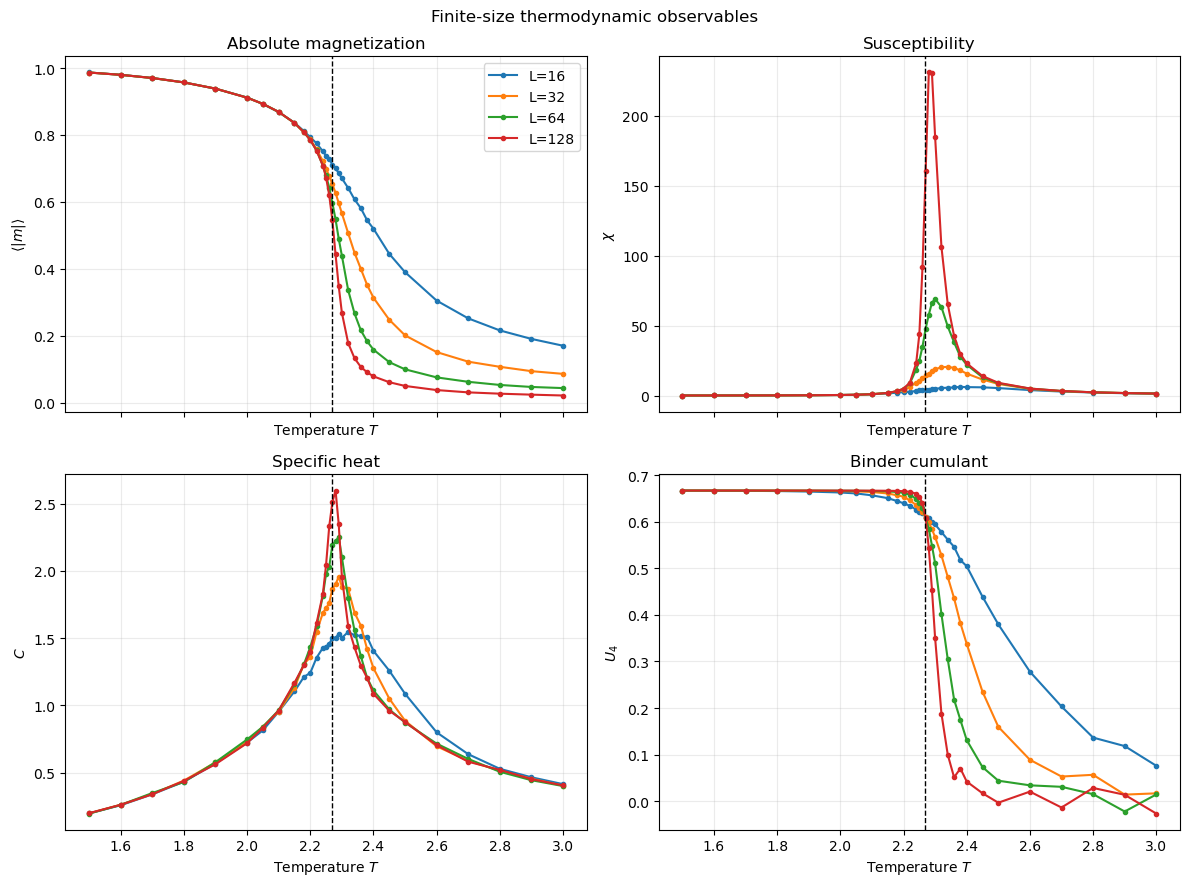

In [3]:
def observables(size, moments):
    mean = moments.mean(axis=0)
    abs_m, m2, m4, energy, e2 = mean.T
    susceptibility = size ** 2 / TEMPERATURES * (m2 - abs_m ** 2)
    specific_heat = size ** 2 / TEMPERATURES ** 2 * (e2 - energy ** 2)
    binder = 1.0 - m4 / (3.0 * m2 ** 2)
    return pd.DataFrame({
        "L": size, "temperature": TEMPERATURES, "abs_m": abs_m,
        "m2": m2, "energy": energy, "susceptibility": susceptibility,
        "specific_heat": specific_heat, "binder": binder,
    })

curves = pd.concat([
    observables(size, moment_data[size]["moments"]) for size in SIZES
], ignore_index=True)
curves.to_csv(OUTPUT_ROOT / "ising_finite_size_thermodynamic_curves.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
for size in SIZES:
    data = curves[curves.L == size]
    axes[0, 0].plot(data.temperature, data.abs_m, "o-", ms=3, label=f"L={size}")
    axes[0, 1].plot(data.temperature, data.susceptibility, "o-", ms=3)
    axes[1, 0].plot(data.temperature, data.specific_heat, "o-", ms=3)
    axes[1, 1].plot(data.temperature, data.binder, "o-", ms=3)
for ax in axes.ravel():
    ax.axvline(EXACT_TC, color="black", ls="--", lw=1)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Temperature $T$")
axes[0, 0].set(ylabel=r"$\langle|m|\rangle$", title="Absolute magnetization")
axes[0, 1].set(ylabel=r"$\chi$", title="Susceptibility")
axes[1, 0].set(ylabel=r"$C$", title="Specific heat")
axes[1, 1].set(ylabel=r"$U_4$", title="Binder cumulant")
axes[0, 0].legend()
fig.suptitle("Finite-size thermodynamic observables")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising_finite_size_thermodynamic_curves.png", dpi=250, bbox_inches="tight")
plt.show()

## Pseudocritical temperatures

Cubic interpolation is used only inside the densely sampled transition window $2.1\le T\le2.4$. Peak positions are extracted for the susceptibility, specific heat, and magnetization derivative. Binder crossings are computed with shape-preserving interpolation.

In [4]:
dense_t = np.linspace(2.10, 2.40, 3001)
peak_rows = []
for size in SIZES:
    data = curves[curves.L == size]
    t = data.temperature.to_numpy()
    abs_m_spline = CubicSpline(t, data.abs_m)
    susceptibility_spline = CubicSpline(t, data.susceptibility)
    heat_spline = CubicSpline(t, data.specific_heat)
    binder_spline = CubicSpline(t, data.binder)
    diagnostics = {
        "magnetization_derivative": -abs_m_spline(dense_t, 1),
        "susceptibility": susceptibility_spline(dense_t),
        "specific_heat": heat_spline(dense_t),
        "log_m_derivative": -abs_m_spline(dense_t, 1) / abs_m_spline(dense_t),
        "binder_slope": np.abs(binder_spline(dense_t, 1)),
    }
    for estimator, values in diagnostics.items():
        index = int(np.argmax(values))
        peak_rows.append({"L": size, "estimator": estimator, "peak_temperature": dense_t[index], "peak_height": values[index]})

peaks = pd.DataFrame(peak_rows)
peaks.to_csv(OUTPUT_ROOT / "ising_finite_size_peak_estimates.csv", index=False)
peaks.pivot(index="L", columns="estimator", values="peak_temperature")

estimator,binder_slope,log_m_derivative,magnetization_derivative,specific_heat,susceptibility
L,,,,,
16,2.3693,2.3711,2.2651,2.3236,2.3824
32,2.3699,2.3723,2.2876,2.2897,2.3298
64,2.3134,2.3138,2.2850,2.2884,2.3005
128,2.2954,2.2954,2.2769,2.2784,2.2846


In [5]:
crossing_rows = []
for low_size, high_size in zip(SIZES[:-1], SIZES[1:]):
    low = curves[curves.L == low_size]
    high = curves[curves.L == high_size]
    difference = PchipInterpolator(TEMPERATURES, low.binder)(dense_t) - PchipInterpolator(TEMPERATURES, high.binder)(dense_t)
    roots = []
    for i in range(len(dense_t) - 1):
        if difference[i] * difference[i + 1] < 0:
            roots.append(brentq(PchipInterpolator(dense_t, difference), dense_t[i], dense_t[i + 1]))
    crossing = min(roots, key=lambda value: abs(value - EXACT_TC)) if roots else np.nan
    crossing_rows.append({"L_low": low_size, "L_high": high_size, "binder_crossing": crossing})

crossings = pd.DataFrame(crossing_rows)
crossings.to_csv(OUTPUT_ROOT / "ising_binder_crossings.csv", index=False)
crossings

,L_low,L_high,binder_crossing
0,16,32,2.268137
1,32,64,2.269487
2,64,128,2.269966


## Finite-size extrapolation of $T_c$

For the 2D Ising universality class, $\nu=1$, so leading pseudocritical shifts are linear in $1/L$. Separate fits are shown because different peak definitions carry different corrections to scaling.

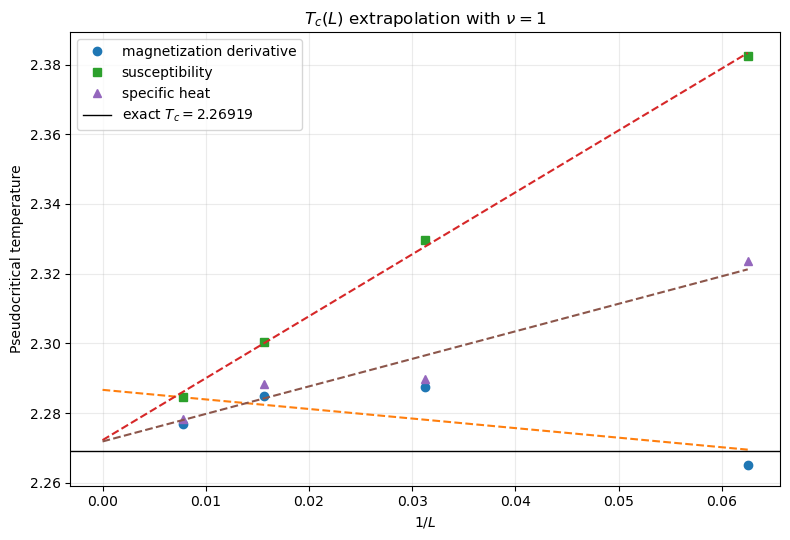

,estimator,Tc_infinite,shift_amplitude,r_squared,intercept_stderr
0,magnetization_derivative,2.286691,-0.274477,0.430490,0.008040
1,susceptibility,2.272265,1.776974,0.998650,0.001664
2,specific_heat,2.271883,0.789927,0.939731,0.005094


In [6]:
tc_fit_rows = []
fig, ax = plt.subplots(figsize=(8, 5.5))
for estimator, marker in [("magnetization_derivative", "o"), ("susceptibility", "s"), ("specific_heat", "^")]:
    data = peaks[peaks.estimator == estimator].sort_values("L")
    x = 1.0 / data.L.to_numpy()
    y = data.peak_temperature.to_numpy()
    fit = linregress(x, y)
    tc_fit_rows.append({"estimator": estimator, "Tc_infinite": fit.intercept, "shift_amplitude": fit.slope, "r_squared": fit.rvalue ** 2, "intercept_stderr": fit.intercept_stderr})
    ax.plot(x, y, marker=marker, ls="none", label=estimator.replace("_", " "))
    grid = np.linspace(0, x.max(), 100)
    ax.plot(grid, fit.intercept + fit.slope * grid, ls="--")
ax.axhline(EXACT_TC, color="black", lw=1, label=f"exact $T_c={EXACT_TC:.5f}$")
ax.set(xlabel="$1/L$", ylabel="Pseudocritical temperature", title=r"$T_c(L)$ extrapolation with $\nu=1$")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising_pseudocritical_extrapolation.png", dpi=250, bbox_inches="tight")
plt.show()

tc_fits = pd.DataFrame(tc_fit_rows)
tc_fits.to_csv(OUTPUT_ROOT / "ising_pseudocritical_extrapolation.csv", index=False)
tc_fits

## Critical power-law checks

Expected 2D Ising exponent ratios are $\gamma/\nu=7/4$, $\beta/\nu=1/8$, and $1/\nu=1$. The specific heat has $\alpha=0$ and therefore grows logarithmically rather than as a nonzero power.

In [7]:
scaling_rows = []

chi_peak = peaks[peaks.estimator == "susceptibility"].sort_values("L").peak_height.to_numpy()
log_m_peak = peaks[peaks.estimator == "log_m_derivative"].sort_values("L").peak_height.to_numpy()
binder_slope = peaks[peaks.estimator == "binder_slope"].sort_values("L").peak_height.to_numpy()
m_at_tc = np.array([
    float(PchipInterpolator(TEMPERATURES, curves[curves.L == size].abs_m)(EXACT_TC))
    for size in SIZES
])
c_peak = peaks[peaks.estimator == "specific_heat"].sort_values("L").peak_height.to_numpy()

for name, values, expected in [
    ("susceptibility_peak", chi_peak, 7/4),
    ("magnetization_at_Tc", m_at_tc, -1/8),
    ("log_m_derivative_peak", log_m_peak, 1.0),
    ("binder_slope_peak", binder_slope, 1.0),
]:
    fit = linregress(np.log(SIZES), np.log(values))
    scaling_rows.append({"observable": name, "fitted_power": fit.slope, "expected_power": expected, "r_squared": fit.rvalue ** 2, "slope_stderr": fit.stderr})

heat_fit = linregress(np.log(SIZES), c_peak)
scaling_rows.append({"observable": "specific_heat_peak_vs_log_L", "fitted_power": heat_fit.slope, "expected_power": np.nan, "r_squared": heat_fit.rvalue ** 2, "slope_stderr": heat_fit.stderr})

scaling = pd.DataFrame(scaling_rows)
scaling.to_csv(OUTPUT_ROOT / "ising_critical_power_law_fits.csv", index=False)
scaling

,observable,fitted_power,expected_power,r_squared,slope_stderr
0,susceptibility_peak,1.755874,1.750,0.999917,0.011333
1,magnetization_at_Tc,-0.122844,-0.125,0.999997,0.000139
2,log_m_derivative_peak,0.986074,1.000,0.998680,0.025353
3,binder_slope_peak,0.935051,1.000,0.997485,0.033202
4,specific_heat_peak_vs_log_L,0.498869,NaN,0.996338,0.021387


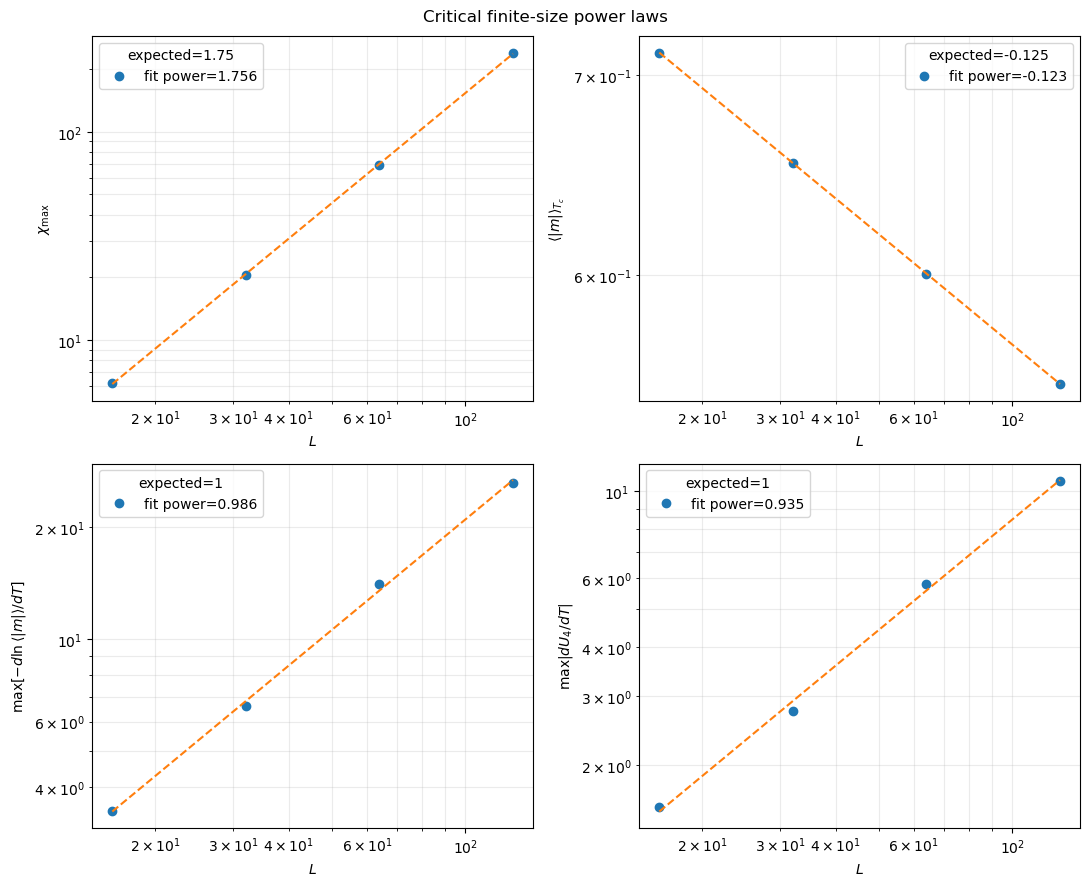

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
series = [
    (chi_peak, r"$\chi_{\max}$", 7/4),
    (m_at_tc, r"$\langle|m|\rangle_{T_c}$", -1/8),
    (log_m_peak, r"$\max[-d\ln\langle|m|\rangle/dT]$", 1.0),
    (binder_slope, r"$\max|dU_4/dT|$", 1.0),
]
for ax, (values, label, expected) in zip(axes.ravel(), series):
    fit = linregress(np.log(SIZES), np.log(values))
    grid = np.geomspace(SIZES.min(), SIZES.max(), 100)
    ax.loglog(SIZES, values, "o", label=f"fit power={fit.slope:.3f}")
    ax.loglog(grid, np.exp(fit.intercept) * grid ** fit.slope, "--")
    ax.set(xlabel="$L$", ylabel=label)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(title=f"expected={expected:g}")
fig.suptitle("Critical finite-size power laws")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising_critical_power_laws.png", dpi=250, bbox_inches="tight")
plt.show()

## Seed-bootstrap uncertainty

The uncertainty calculation resamples the 1,000 independent simulation seeds within each lattice size. Each bootstrap replicate recomputes the susceptibility and specific-heat peak positions, adjacent-size Binder crossings, and the $1/L$ extrapolated infinite-size temperature. This captures Monte Carlo sampling uncertainty but not systematic corrections to the assumed scaling form or interpolation choice.

In [9]:
N_BOOTSTRAP = 300
rng = np.random.default_rng(20260928)
bootstrap_peak_rows = []
bootstrap_crossing_rows = []
bootstrap_tc_rows = []

def curves_from_seed_sample(size, sampled_moments):
    mean = sampled_moments.mean(axis=0)
    abs_m, m2, m4, energy, e2 = mean.T
    return {
        "abs_m": abs_m,
        "susceptibility": size ** 2 / TEMPERATURES * (m2 - abs_m ** 2),
        "specific_heat": size ** 2 / TEMPERATURES ** 2 * (e2 - energy ** 2),
        "binder": 1.0 - m4 / (3.0 * m2 ** 2),
    }

for replicate in range(N_BOOTSTRAP):
    replicate_curves = {}
    replicate_peaks = {"susceptibility": [], "specific_heat": []}
    for size in SIZES:
        indices = rng.integers(0, N_RUNS, N_RUNS)
        values = curves_from_seed_sample(size, moment_data[size]["moments"][indices])
        replicate_curves[size] = values
        for estimator in replicate_peaks:
            dense_values = CubicSpline(TEMPERATURES, values[estimator])(dense_t)
            peak_t = float(dense_t[np.argmax(dense_values)])
            replicate_peaks[estimator].append(peak_t)
            bootstrap_peak_rows.append({
                "replicate": replicate, "L": size,
                "estimator": estimator, "peak_temperature": peak_t,
            })

    for low_size, high_size in zip(SIZES[:-1], SIZES[1:]):
        difference = (
            PchipInterpolator(TEMPERATURES, replicate_curves[low_size]["binder"])(dense_t)
            - PchipInterpolator(TEMPERATURES, replicate_curves[high_size]["binder"])(dense_t)
        )
        roots = []
        interpolated_difference = PchipInterpolator(dense_t, difference)
        for i in range(len(dense_t) - 1):
            if difference[i] * difference[i + 1] < 0:
                roots.append(brentq(interpolated_difference, dense_t[i], dense_t[i + 1]))
        crossing = min(roots, key=lambda value: abs(value - EXACT_TC)) if roots else np.nan
        bootstrap_crossing_rows.append({
            "replicate": replicate, "L_low": low_size,
            "L_high": high_size, "binder_crossing": crossing,
        })

    for estimator, peak_temperatures in replicate_peaks.items():
        fit = linregress(1.0 / SIZES, peak_temperatures)
        bootstrap_tc_rows.append({
            "replicate": replicate, "estimator": estimator,
            "Tc_infinite": fit.intercept,
        })

bootstrap_peaks = pd.DataFrame(bootstrap_peak_rows)
bootstrap_crossings = pd.DataFrame(bootstrap_crossing_rows)
bootstrap_tc = pd.DataFrame(bootstrap_tc_rows)

def interval_table(frame, group_columns, value_column):
    return frame.groupby(group_columns)[value_column].agg(
        mean="mean",
        standard_error="std",
        ci_low=lambda x: np.nanpercentile(x, 2.5),
        ci_high=lambda x: np.nanpercentile(x, 97.5),
        valid_replicates="count",
    ).reset_index()

peak_intervals = interval_table(
    bootstrap_peaks, ["L", "estimator"], "peak_temperature"
)
crossing_intervals = interval_table(
    bootstrap_crossings, ["L_low", "L_high"], "binder_crossing"
)
tc_intervals = interval_table(
    bootstrap_tc, ["estimator"], "Tc_infinite"
)

peak_intervals.to_csv(OUTPUT_ROOT / "ising_peak_temperature_bootstrap_intervals.csv", index=False)
crossing_intervals.to_csv(OUTPUT_ROOT / "ising_binder_crossing_bootstrap_intervals.csv", index=False)
tc_intervals.to_csv(OUTPUT_ROOT / "ising_Tc_extrapolation_bootstrap_intervals.csv", index=False)

display(crossing_intervals)
display(tc_intervals)

,L_low,L_high,mean,standard_error,ci_low,ci_high,valid_replicates
0,16,32,2.267239,0.003470,2.260220,2.272599,300
1,32,64,2.269442,0.001257,2.267185,2.271957,300
2,64,128,2.269965,0.000771,2.268539,2.271435,300


,estimator,mean,standard_error,ci_low,ci_high,valid_replicates
0,specific_heat,2.271103,0.007377,2.253767,2.283257,300
1,susceptibility,2.272359,0.002078,2.268283,2.276588,300


## Interpretation

The Binder crossings provide the cleanest direct estimate of the transition. They move from 2.26814 ($L=16,32$) to 2.26949 ($L=32,64$) and 2.26997 ($L=64,128$), tightly surrounding the exact value $T_c=2.26919$. The seed-bootstrap 95% interval for the largest pair is 2.26854–2.27143.

Susceptibility-peak shifts are also highly linear in $1/L$ ($R^2=0.9986$), giving $T_c(\infty)=2.27236$ with a seed-bootstrap 95% interval of 2.26828–2.27659. Specific heat is compatible but less precise. The raw magnetization-derivative peak is not monotonic across these four sizes and should not be used as the primary $T_c$ estimator.

The critical scaling checks strongly validate the simulation data:

- $\chi_{\max}\sim L^{1.756}$, compared with exact $\gamma/\nu=1.75$;
- $\langle|m|\rangle_{T_c}\sim L^{-0.12284}$, compared with exact $-\beta/\nu=-0.125$;
- $\max[-d\ln\langle|m|\rangle/dT]\sim L^{0.986}$, compared with exact $1/\nu=1$;
- $\max|dU_4/dT|\sim L^{0.935}$, approaching the expected $1/\nu=1$;
- the specific-heat maximum grows approximately linearly with $\log L$, as expected for the 2D Ising model's $\alpha=0$ logarithmic singularity.
